In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [2]:
def calculate_green_proportion(image):
    """Calculate proportion of green intensity to total RGB intensity."""
    image = image.astype(np.float32)
    total_intensity = np.sum(image, axis=2)
    total_intensity[total_intensity == 0] = 1  # avoid division by zero
    green_proportion = image[:, :, 1] / total_intensity
    return np.mean(green_proportion)

In [3]:
def run_green_intensity_eda(image_dir, output_csv="green_proportions.csv"):
    proportions = []
    filenames = []

    for file in tqdm(os.listdir(image_dir)):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(image_dir, file)
            image = cv2.imread(path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            prop = calculate_green_proportion(image)
            proportions.append(prop)
            filenames.append(file)

    # Create DataFrame and save to CSV
    df = pd.DataFrame({
        "filename": filenames,
        "green_proportion": proportions
    })
    df.to_csv(output_csv, index=False)

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(proportions, bins=30, color='green', alpha=0.7, edgecolor='black')
    plt.title("Distribution of Green Pixel Intensity Proportion")
    plt.xlabel("Average Green Proportion")
    plt.ylabel("Number of Images")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Saved green proportions to {output_csv}")
    return df

100%|██████████| 9830/9830 [31:14<00:00,  5.24it/s]


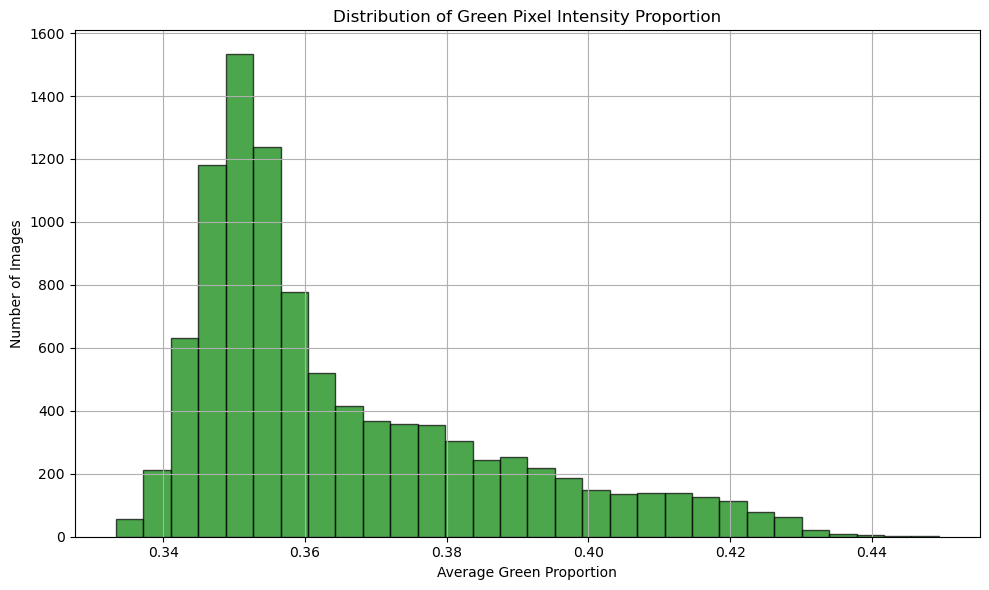

Saved green proportions to /mnt/research-projects/j/jlgage/RawUAVData01/data/green_pixel_proportions.csv


In [4]:
# Example usage
image_directory = "/mnt/research-projects/j/jlgage/RawUAVData01/data/images"  # replace with your actual path
output_csv_file = "/mnt/research-projects/j/jlgage/RawUAVData01/data/green_pixel_proportions.csv"
df_result = run_green_intensity_eda(image_directory, output_csv_file)